# IMPORT LIBRARY

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# LOAD DATASET

In [5]:
df = pd.read_csv('../data/predictive_maintenance.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# CEK STRUKTUR DATA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [8]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

# EXPLORATORY DATA ANALYSIS

# Distribusi Failure

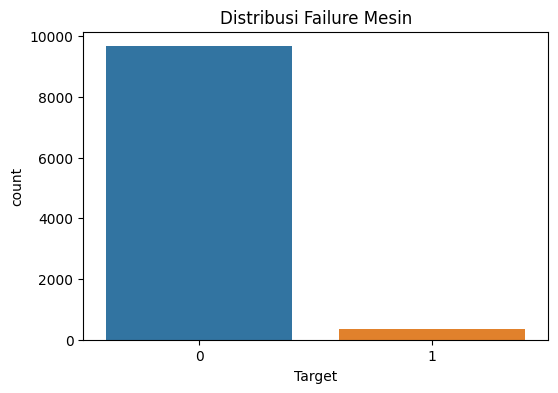

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title('Distribusi Failure Mesin')
plt.show()

# Visualisasi Temperatur

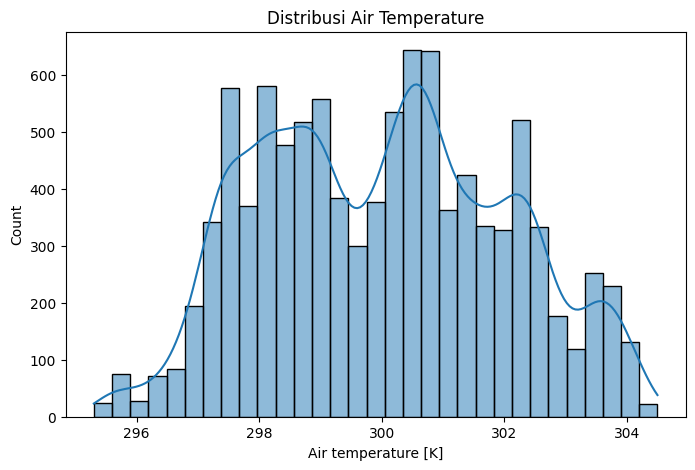

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Air temperature [K]'], kde=True)
plt.title('Distribusi Air Temperature')
plt.show()

# Korelasi Antar Variabel

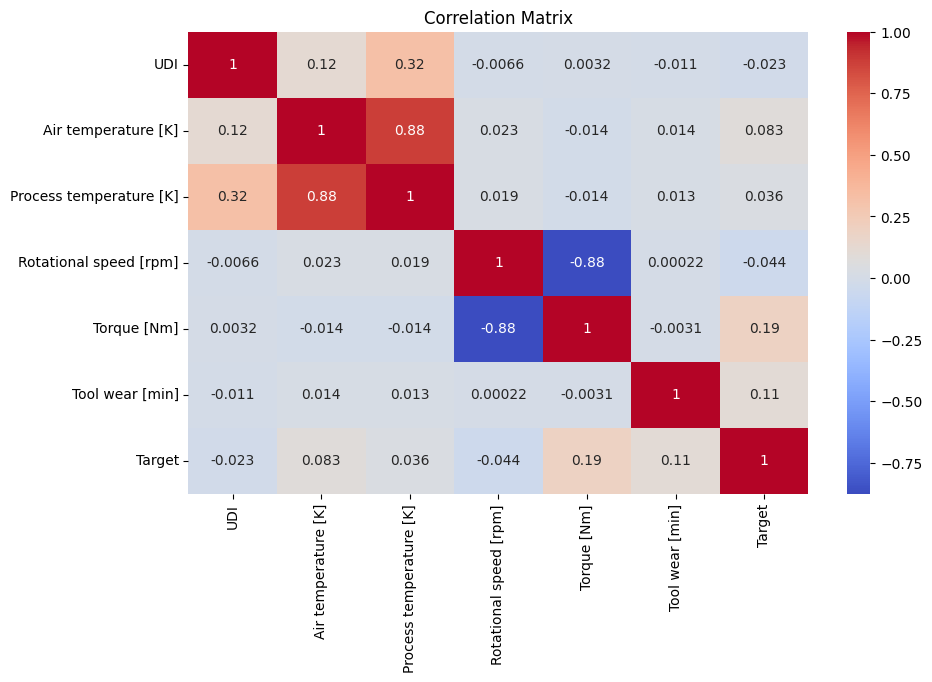

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

# PREPROCESSING

# Ambil Fitur Penting

In [12]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[features]

# Normalisasi Data

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# CONTENT-BASED FILTERING

In [14]:
# Hitung Similarity Mesin
similarity_matrix = cosine_similarity(X_scaled)

# Fungsi Recommendation

In [15]:
def recommend_similar_machines(machine_index, top_n=5):

    similarity_scores = list(enumerate(similarity_matrix[machine_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    machine_indices = [i[0] for i in similarity_scores]

    return df.iloc[machine_indices]

# Testing Recommendation

In [16]:
recommend_similar_machines(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
90,91,L47270,L,298.9,308.9,1753,25.8,33,0,No Failure
92,93,M14952,M,298.9,308.9,1727,27.1,37,0,No Failure
9266,9267,L56446,L,298.2,308.9,1737,25.5,26,0,No Failure
9851,9852,M24711,M,298.5,309.3,1761,27.2,49,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


# Encode Failure Type

In [17]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

# Label Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['failure_encoded'] = encoder.fit_transform(df['Failure Type'])

# Cek hasil encoding

In [19]:
df[['Failure Type', 'failure_encoded']].head()

,Failure Type,failure_encoded
0,No Failure,1
1,No Failure,1
2,No Failure,1
3,No Failure,1
4,No Failure,1


# Buat Interaction Matrix

In [20]:
interaction_matrix = pd.pivot_table(
    df,
    values='failure_encoded',
    index='UDI',
    columns='Type',
    fill_value=0
)

interaction_matrix.head()

Type,H,L,M
UDI,,,
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
5,0.0,1.0,0.0


# Similarity Matrix

In [21]:
machine_similarity = cosine_similarity(interaction_matrix)

# Collaborative Recommendation Function

In [22]:
def collaborative_recommendation(machine_id, top_n=5):

    idx = interaction_matrix.index.get_loc(machine_id)

    similarity_scores = list(enumerate(machine_similarity[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    machine_indices = [
        interaction_matrix.index[i[0]]
        for i in similarity_scores
    ]

    return df[df['UDI'].isin(machine_indices)]

# Testing

In [23]:
collaborative_recommendation(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,failure_encoded
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,1
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,1
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,1
12,13,M14872,M,298.6,309.1,1339,51.1,34,0,No Failure,1
13,14,M14873,M,298.6,309.2,1742,30.0,37,0,No Failure,1


In [24]:
!pip install scikit-surprise

Defaulting to user installation because normal site-packages is not writeable


In [25]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

# Siapkan Data

In [26]:
ratings = df[['UDI', 'failure_encoded']].copy()

ratings['rating'] = 1

# Reader

In [27]:
reader = Reader(rating_scale=(0, 1))

data = Dataset.load_from_df(
    ratings[['UDI', 'failure_encoded', 'rating']],
    reader
)

# Split Data

In [28]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# Train SVD

In [29]:
model = SVD()

model.fit(trainset)

# Prediction

In [30]:
predictions = model.test(testset)

rmse(predictions)

RMSE: 0.0023


0.002273065519965773

# HYBRID RECOMMENDATION

# Hybrid Function

In [31]:
def hybrid_recommendation(machine_index):

    content_result = recommend_similar_machines(machine_index, top_n=3)

    collaborative_result = collaborative_recommendation(
        df.iloc[machine_index]['UDI'],
        top_n=3
    )

    hybrid_result = pd.concat([
        content_result,
        collaborative_result
    ]).drop_duplicates()

    return hybrid_result

In [32]:
hybrid_recommendation(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,failure_encoded
90,91,L47270,L,298.9,308.9,1753,25.8,33,0,No Failure,1
92,93,M14952,M,298.9,308.9,1727,27.1,37,0,No Failure,1
9266,9267,L56446,L,298.2,308.9,1737,25.5,26,0,No Failure,1
11,12,H29425,H,298.6,309.1,1423,44.3,29,0,No Failure,1
18,19,H29432,H,298.8,309.2,1306,54.5,50,0,No Failure,1
20,21,H29434,H,298.9,309.3,1375,42.7,58,0,No Failure,1


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

In [34]:
similarity_scores = similarity_matrix.mean()

print("Average Similarity Score:")
print(similarity_scores)

Average Similarity Score:
0.002250981132061688


In [35]:
hybrid_result = hybrid_recommendation(10)

print("Jumlah rekomendasi:")
print(len(hybrid_result))

Jumlah rekomendasi:
6
